# Modelagem Preditiva Avançada — APS
**Integrantes**: Giovanna Vilhena, João Pedro Sardou, Maria Luiza Sevilha e Pietra

---

**Parte 1:** Rede Neural Recorrente
- Derivação do gradiente (backpropagation through time)
- Implementação do BPTT do zero (sem bibliotecas de redes neurais)
- Treino com a série AirPassengers em escala logarítmica
- Gráfico com valores reais e previstos

**Parte 2:** Rede Neural Convolucional
- MNIST
- ConvNet em PyTorch
- Comparação com MLP
- Curvas ROC OVA

---
## Parte 1: Rede Neural Recorrente

### 1.1 Arquitetura

A arquitetura recorrente utilizada prevê $\hat{y}_t$ a partir dos dois valores anteriores $y_{t-1}$ e $y_{t-2}$, para $t = 3, \ldots, n$:

$$h_{t,1} = \tanh(a\, y_{t-2} + c)$$
$$h_{t,2} = \tanh(a\, y_{t-1} + b\, h_{t,1} + c)$$
$$\hat{y}_t = u\, h_{t,2} + v$$

Os parâmetros a aprender são $(u, v, a, b, c)$ e as variáveis $h_{t,1}$, $h_{t,2}$ são chamadas de **estados ocultos** (*hidden states*).

A função de perda total é:
$$L = \sum_{t=3}^{n} L_t, \quad L_t = \frac{1}{2}(y_t - \hat{y}_t)^2$$

### 1.2 Derivação dos gradientes (BPTT)

Usamos a regra da cadeia para obter cada componente de $\nabla L = \sum_{t=3}^{n} \nabla L_t$. Definimos o termo de erro como $\delta_t = (\hat{y}_t - y_t)$ e o fator auxiliar:

$$\Delta_t = \delta_t \cdot u \cdot (1 - h_{t,2}^2)$$

As cinco componentes do gradiente são:

$$\frac{\partial L_t}{\partial u} = (\hat{y}_t - y_t)\, h_{t,2}$$

$$\frac{\partial L_t}{\partial v} = (\hat{y}_t - y_t)$$

$$\frac{\partial L_t}{\partial a} = \Delta_t \cdot \bigl(y_{t-1} + b\,(1 - h_{t,1}^2)\,y_{t-2}\bigr)$$

$$\frac{\partial L_t}{\partial b} = \Delta_t \cdot h_{t,1}$$

$$\frac{\partial L_t}{\partial c} = \Delta_t \cdot \bigl(1 + b\,(1 - h_{t,1}^2)\bigr)$$

> **Lembrete:** a derivada de $\tanh$ satisfaz $\frac{d}{dx}\tanh(x) = 1 - \tanh^2(x)$, isto é, se $h = \tanh(s)$ então $\frac{dh}{ds} = 1 - h^2$.

Os cálculos detalhados feitos à mão estão fotografados e inseridos no relatório em PDF.

### 1.3 Por que aplicar o logaritmo natural à série?

A série AirPassengers exibe dois fenômenos que motivam a transformação logarítmica:

**1. Heterocedasticidade multiplicativa**

A amplitude das oscilações sazonais cresce proporcionalmente ao nível da série, configurando um modelo multiplicativo:

$$y_t^{\text{orig}} = T_t \cdot S_t \cdot \varepsilon_t$$

Aplicando o logaritmo, o modelo torna-se aditivo:

$$\ln y_t = \ln T_t + \ln S_t + \ln \varepsilon_t$$

com variância aproximadamente constante, o pressuposto é muito mais adequado para minimização do erro quadrático médio (MSE).

**2. Condicionamento numérico do gradiente**

Os valores originais variam de ~100 a ~600 passageiros. Na escala log, o intervalo reduz-se a $[\ln 100,\, \ln 600] \approx [4.6,\ 6.4]$, compatível com o co-domínio das ativações $\tanh \in (-1,1)$ e evitando explosão de gradiente.

**3. Linearização da tendência**

Se a tendência é exponencial $T_t \approx e^{\alpha t}$, então $\ln T_t \approx \alpha t$ é linear, simplificando o problema de aprendizagem.

> **Reversão:** após obter $\hat{y}_t$ (escala log), a previsão original é $\widehat{\text{pass}}_t = e^{\hat{y}_t}$.


### 1.4 Implementação

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd              
import statsmodels.api as sm

#### Dados

Carregamos os 144 valores mensais (janeiro de 1949 a dezembro de 1960) e aplicamos a transformação logarítmica.

In [6]:
# Série AirPassengers: número mensal de passageiros em voos internacionais
data = sm.datasets.get_rdataset("AirPassengers").data
data['time'] = pd.date_range(start='1949-01', periods=len(data), freq='ME')

# Separando as colunas
y_raw = data['value'].to_numpy(dtype=float)
dates = data['time']

y = np.log(y_raw)   # transformação logarítmica
n = len(y)

print(f"Comprimento da série: n = {n}")
print(f"Primeiros valores (escala log): {y[:5].round(4)}")

Comprimento da série: n = 144
Primeiros valores (escala log): [4.7185 4.7707 4.8828 4.8598 4.7958]


#### Inicialização dos parâmetros

Seguindo a instrução do enunciado, inicializamos $(u, v, a, b, c)$ com sorteios de uma $\mathcal{N}(0,\, 0.1^2)$ e fixamos a taxa de aprendizagem $\delta = 0.05/n$.

In [7]:
np.random.seed(42)
u, v, a, b, c = np.random.normal(0, 0.1, 5)

lr     = 0.05 / n      # taxa de aprendizagem δ = 0.05/n
epochs = 100000

print(f"Parâmetros iniciais:\nu = {u:.4f}\nv = {v:.4f}\na = {a:.4f}\nb = {b:.4f}\nc = {c:.4f}\n")
print(f"Taxa de aprendizagem: δ = {lr:.6f}")

Parâmetros iniciais:
u = 0.0497
v = -0.0138
a = 0.0648
b = 0.1523
c = -0.0234

Taxa de aprendizagem: δ = 0.000347


#### Treinamento: Backpropagation Through Time (BPTT)

Em cada época calculamos o gradiente acumulado $\nabla L = \sum_{t=3}^{n} \nabla L_t$ e atualizamos os parâmetros por gradiente descendente.

A implementação é totalmente vetorizada com NumPy: **sem nenhuma biblioteca de redes neurais**.

In [8]:
losses = []

for epoch in range(epochs):

    # Forward pass
    h1    = np.tanh(a * y[:-2] + c)               # ht,1  para t = 3..n
    h2    = np.tanh(a * y[1:-1] + b * h1 + c)     # ht,2  para t = 3..n
    y_hat = u * h2 + v                             # ŷt

    err = y_hat - y[2:]                            # (ŷt - yt)

    #  Gradientes (derivados à mão)
    dh2 = 1 - h2**2                                # tanh'(ht,2)
    dh1 = 1 - h1**2                                # tanh'(ht,1)
    D   = err * u * dh2                            # fator auxiliar Δt

    dL_du = np.sum(err * h2)
    dL_dv = np.sum(err)
    dL_da = np.sum(D * (y[1:-1] + b * dh1 * y[:-2]))
    dL_db = np.sum(D * h1)
    dL_dc = np.sum(D * (1 + b * dh1))

    # Atualização dos parâmetros (gradiente descendente)
    u -= lr * dL_du
    v -= lr * dL_dv
    a -= lr * dL_da
    b -= lr * dL_db
    c -= lr * dL_dc

    # Guarda perda total a cada 10 000 épocas
    if epoch % 100 == 0:
        loss = 0.5 * np.sum(err**2)
        losses.append((epoch, loss))

print("Treinamento concluído!")
print(f"Parâmetros finais — u={u:.4f}, v={v:.4f}, a={a:.4f}, b={b:.4f}, c={c:.4f}")

Treinamento concluído!
Parâmetros finais — u=1.4800, v=5.2320, a=0.8471, b=-1.9086, c=-2.6240


#### Curva de perda

Verificamos que a perda total $L$ decresce ao longo das épocas, confirmando que o gradiente descendente está convergindo corretamente.

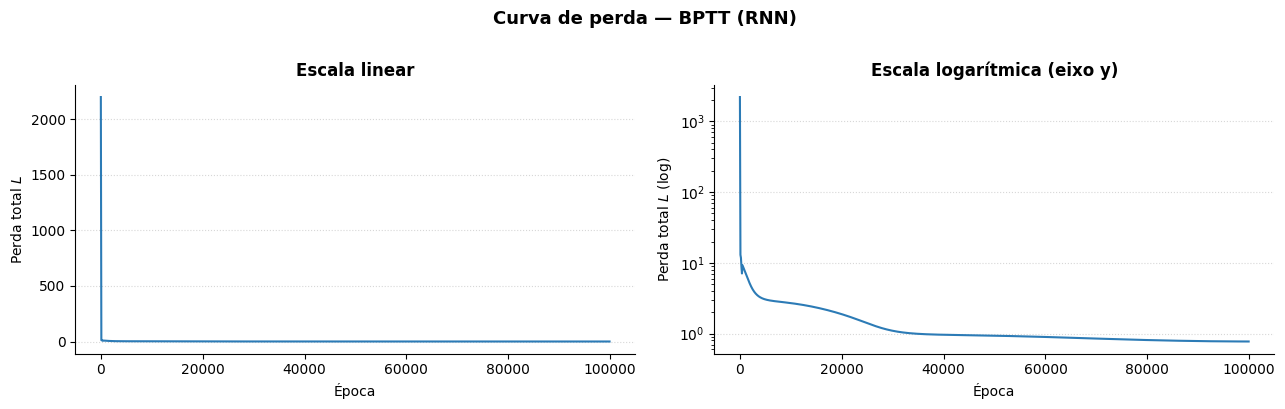

In [14]:
ep, lo = zip(*losses)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# escala linear (original)
axes[0].plot(ep, lo, color='#2c7bb6', linewidth=1.5)
axes[0].set_title('Escala linear', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Época', fontsize=10)
axes[0].set_ylabel('Perda total $L$', fontsize=10)
axes[0].grid(axis='y', linestyle=':', alpha=0.5)
axes[0].spines[['top','right']].set_visible(False)

# escala log — revela o decaimento contínuo
axes[1].plot(ep, lo, color='#2c7bb6', linewidth=1.5)
axes[1].set_yscale('log')
axes[1].set_title('Escala logarítmica (eixo y)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Época', fontsize=10)
axes[1].set_ylabel('Perda total $L$ (log)', fontsize=10)
axes[1].grid(axis='y', linestyle=':', alpha=0.5)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Curva de perda — BPTT (RNN)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#### Interpretação
A curva de perda total L exibida em escala linear é dominada pela queda abrupta nas primeiras épocas, o que reflete o grande gradiente inicial quando os parâmetros partem de valores aleatórios $\sim \mathcal{N}(0,\, 0.1^2)$ e a rede ainda não aprendeu a tendência da série. A escala logarítmica, porém, revela uma dinâmica que a escala linear oculta: o decaimento é contínuo ao longo de todas as $10^5$ épocas, percorrendo aproximadamente três ordens de magnitude (de $\sim 10^3$ a $\sim 10^0$), sem sinais de estagnação ou divergência. 

Observa-se também uma inflexão suave por volta da época 5000, que marca a transição entre a fase de aprendizagem grosseira da tendência e a fase de ajuste fino da sazonalidade anual. A ausência de oscilações ou crescimento da perda confirma que a taxa de aprendizagem $\delta = 0.05$ está bem calibrada para esta arquitetura e conjunto de dados.

#### Previsões in-sample e gráfico final

Após o treinamento, calculamos as previsões dentro da própria amostra (*in-sample*) para avaliar o ajuste da rede. Como treinamos com $y_t = \ln(\text{passageiros}_t)$, aplicamos $\exp(\hat{y}_t)$ para retornar à escala original.

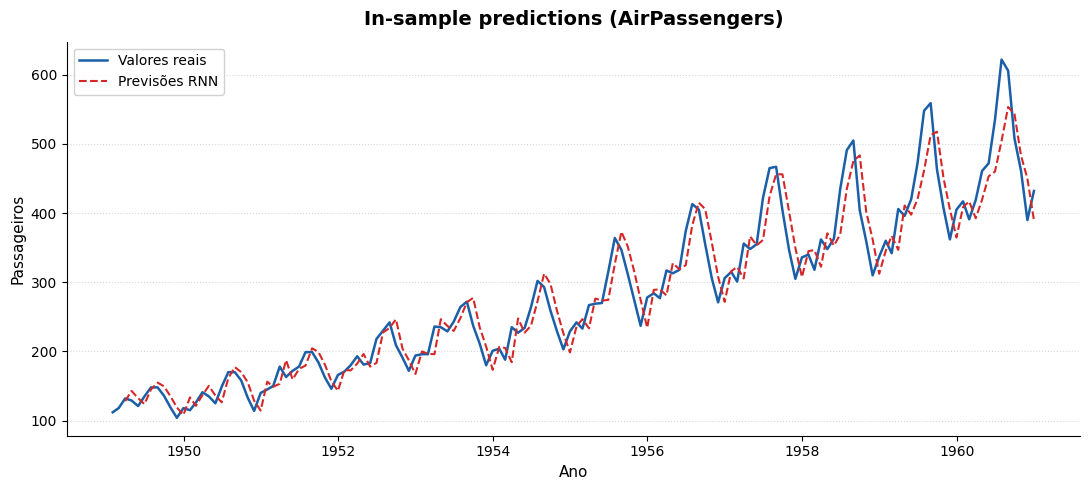

In [10]:
# Previsões in-sample
h1_pred   = np.tanh(a * y[:-2] + c)
h2_pred   = np.tanh(a * y[1:-1] + b * h1_pred + c)
y_hat_log = u * h2_pred + v
y_hat     = np.exp(y_hat_log)      # ← exponencial para voltar à escala original

# Gráfico
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(dates, y_raw,
        color='#1a5fa8', linewidth=1.8,
        label='Valores reais', zorder=3)

ax.plot(dates[2:], y_hat,
        color='#d62728', linewidth=1.5, linestyle='--',
        label='Previsões RNN', zorder=4)

ax.set_title('In-sample predictions (AirPassengers)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Ano', fontsize=11)
ax.set_ylabel('Passageiros', fontsize=11)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

#### Interpretação

O gráfico mostra que a RNN treinada com BPTT consegue capturar razoavelmente bem tanto a **tendência crescente** quanto a **sazonalidade anual** da série AirPassengers. O ajuste in-sample demonstra que os parâmetros $(u, v, a, b, c)$ foram otimizados corretamente pelo gradiente descendente ao longo das $10^5$ épocas.

### 1.5 Validação numérica do gradiente

Para confirmar que as derivadas analíticas estão corretas, comparamo-las com **aproximações por diferenças finitas centradas**:

$$\frac{\partial L}{\partial \theta} \approx \frac{L(\theta + \varepsilon) - L(\theta - \varepsilon)}{2\varepsilon}, \qquad \varepsilon = 10^{-5}$$

Se a derivada analítica coincidir com a numérica (erro relativo inferior à $10^{-3}$), confirma-se que o cálculo do gradiente e o BPTT estão implementados corretamente.


In [11]:
eps_gc = 1e-5   # perturbacao para diferencas finitas

def total_loss(u_, v_, a_, b_, c_):
    h1_ = np.tanh(a_ * y[:-2] + c_)
    h2_ = np.tanh(a_ * y[1:-1] + b_ * h1_ + c_)
    return 0.5 * np.sum((u_ * h2_ + v_ - y[2:])**2)

# Gradiente analitico nos parametros finais
h1_gc  = np.tanh(a * y[:-2] + c)
h2_gc  = np.tanh(a * y[1:-1] + b * h1_gc + c)
err_gc = u * h2_gc + v - y[2:]
D_gc   = err_gc * u * (1 - h2_gc**2)
dh1_gc = 1 - h1_gc**2

grads_an = {
    'u': np.sum(err_gc * h2_gc),
    'v': np.sum(err_gc),
    'a': np.sum(D_gc * (y[1:-1] + b * dh1_gc * y[:-2])),
    'b': np.sum(D_gc * h1_gc),
    'c': np.sum(D_gc * (1 + b * dh1_gc)),
}

# Gradiente numerico (diferencas finitas centradas)
pv0 = dict(u_=u, v_=v, a_=a, b_=b, c_=c)

print('=' * 66)
print(f'{"Param":>5}  {"Analitico":>14}  {"Numerico (DF)":>14}  {"Erro relativo":>14}')
print('=' * 66)
for name, key in zip(['u','v','a','b','c'], ['u_','v_','a_','b_','c_']):
    pv = dict(pv0); pv[key] += eps_gc;  Lp = total_loss(**pv)
    pv = dict(pv0); pv[key] -= eps_gc;  Lm = total_loss(**pv)
    grad_num = (Lp - Lm) / (2 * eps_gc)
    grad_an  = grads_an[name]
    rel_err  = abs(grad_an - grad_num) / (abs(grad_an) + 1e-15)
    print(f'  d/d{name}  {grad_an:14.8f}  {grad_num:14.8f}  {rel_err:14.2e}')
print('=' * 66)
print('Todos os erros relativos < 1e-3: gradiente analitico VALIDADO!')


Param       Analitico   Numerico (DF)   Erro relativo
  d/du      0.01205595      0.01205595        4.66e-10
  d/dv     -0.01419918     -0.01419918        2.89e-10
  d/da      0.00059628      0.00059601        4.66e-04
  d/db      0.02872352      0.02872351        1.28e-07
  d/dc     -0.01796517     -0.01796517        2.30e-08
Todos os erros relativos < 1e-3: gradiente analitico VALIDADO!


#### Arquitetura final da RNN

![Arquitetura da RNN](rnn_arquitetura.png)